In [54]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.animation import FuncAnimation, PillowWriter
from numba import njit
import matplotlib.colors as mcolors
%matplotlib inline

In [34]:
# Parameters
L = 15#5.0
Ngrid = 210#70
dx = L / Ngrid

dt = 0.001
nsteps = 500000

dw = 1.0
dn = 0.001
m = 0.08
a = 0.27

sigma = 0.05  # noise amplitude 

np.random.seed(1)

W = np.random.rand(Ngrid, Ngrid)
Nfield = np.random.rand(Ngrid, Ngrid)

# Simulation colors
colors = [
    "#d95f02",  
    "#fdae61",  
    "#fee08b",  
    "#d9ec94",  
    "#a5d271",
    "#60b53e",
    "#4ba973",
    "#218D43",
]

desert_green = mcolors.LinearSegmentedColormap.from_list(
    "desert_green",
    colors,
    N=256
)

In [35]:
@njit
def laplacian(Z):

    nx, ny = Z.shape
    lap = np.empty_like(Z)

    for i in range(nx):

        ip = (i + 1) % nx
        im = (i - 1) % nx

        for j in range(ny):

            jp = (j + 1) % ny
            jm = (j - 1) % ny

            lap[i, j] = (
                Z[ip, j] +
                Z[im, j] +
                Z[i, jp] +
                Z[i, jm] -
                4 * Z[i, j]
            ) / (dx * dx)

    return lap

In [36]:
@njit
def step(W, N, a_current, dt, dw, dn, m):

    lapW = laplacian(W)
    lapN = laplacian(N)

    W_new = W + dt * (
        a_current
        - W
        - W * N * N
        + dw * lapW
    )

    N_new = N + dt * (
        W * N * N
        - m * N
        + dn * lapN
    )

    return W_new, N_new

In [37]:
# Simulation loop

# Snapshots for visualization
n = 3
total_snapshots = n * n
snapshot_step = nsteps // total_snapshots
snapshots = []
snapshot_times = []

# Snapshots for GIF
gif_frames = []
gif_step = 2000   

# Data for plotting standard deviation over time
stds = []
tempos = []

# Data for funcitonal network
functional_steps = 100
functional_snapshots = []
functional_times = []
burn_in = nsteps // 2

print("Simulation running...")

for i in range(nsteps):

    W, Nfield = step(W, Nfield, a, dt, dw, dn, m)
    W = W + sigma * np.random.randn(*W.shape)

    # Passing the transient phase
    if i >= burn_in:
        if i % functional_steps == 0:
            functional_snapshots.append(Nfield.copy())
            functional_times.append(i * dt)

    if i % snapshot_step == 0 and len(snapshots) < total_snapshots:
        snapshots.append(Nfield.copy())
        snapshot_times.append(i * dt)
        print(f"snapshot t={i*dt:.0f}")

    if i % gif_step == 0:
        gif_frames.append(Nfield.copy())

    if i % 1000 == 0:
        stds.append(np.std(Nfield))
        tempos.append(i * dt)

print("Simulation concluded.")

Simulation running...
snapshot t=0
snapshot t=56
snapshot t=111
snapshot t=167
snapshot t=222
snapshot t=278
snapshot t=333
snapshot t=389
snapshot t=444
Simulation concluded.


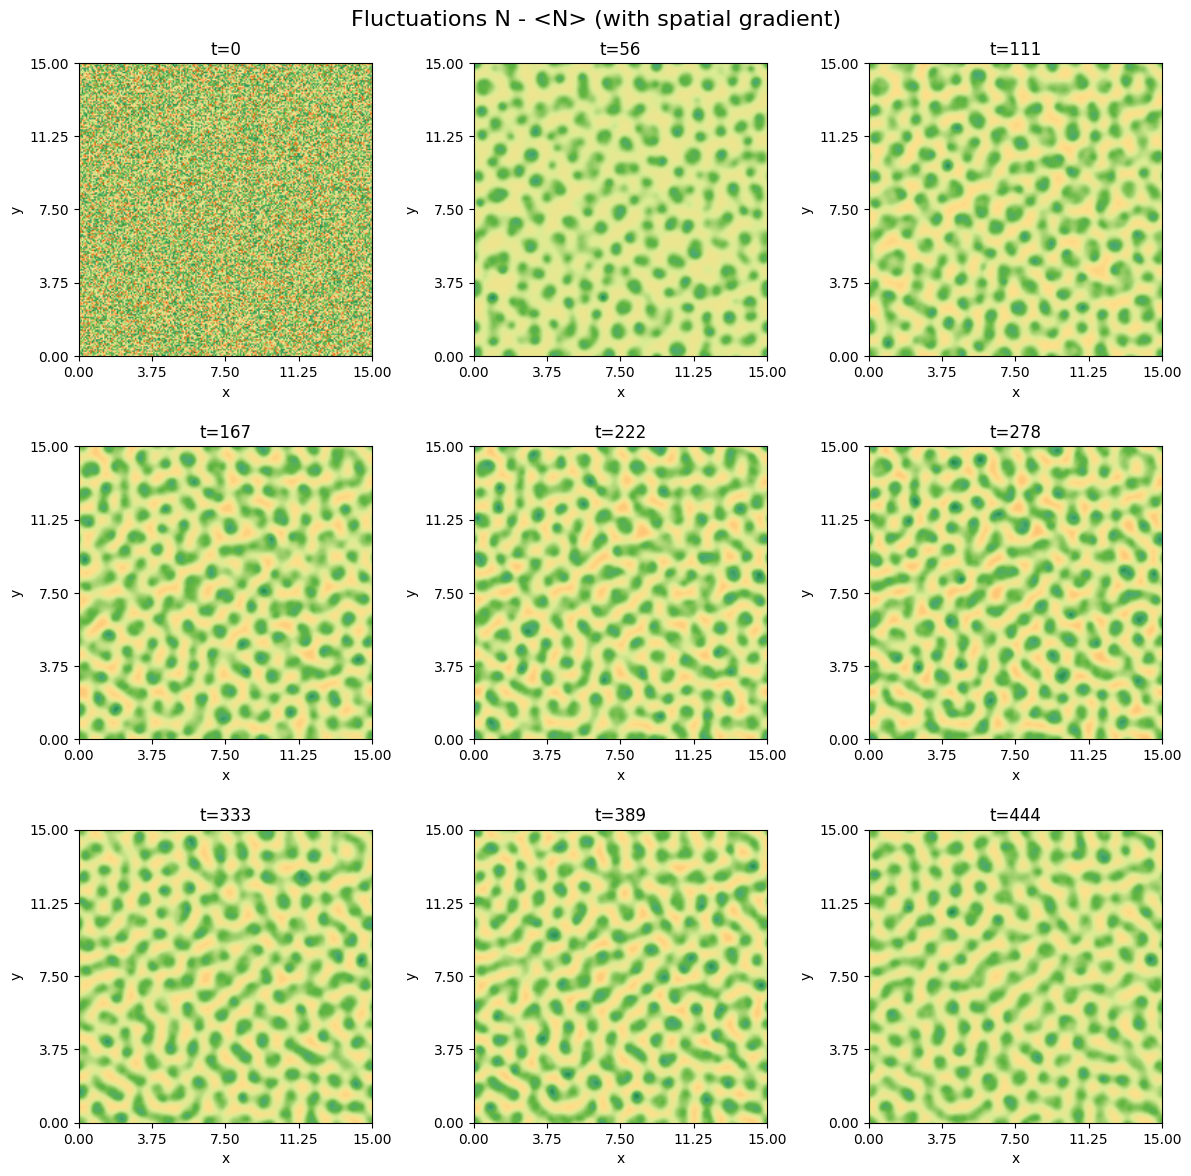

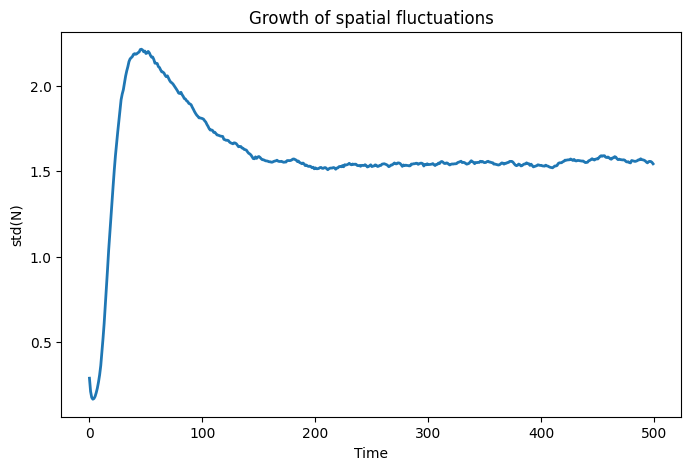

In [38]:
# Plotting snapshots
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for k, ax in enumerate(axes.flat):

    field = snapshots[k]

    fluct = field - np.mean(field)
    fluct = fluct / (np.std(fluct) + 1e-12)

    lim = np.max(np.abs(fluct))

    im = ax.imshow(
        fluct,
        cmap=desert_green,
        vmin=-lim,
        vmax=lim,
        interpolation='bilinear',
        extent=[0, L, 0, L]
    )

    ax.set_title(f"t={snapshot_times[k]:.0f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xticks(np.linspace(0, L, 5))
    ax.set_yticks(np.linspace(0, L, 5))

plt.suptitle("Fluctuations N - <N> (with spatial gradient)", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(tempos, stds, lw=2)
plt.xlabel("Time")
plt.ylabel("std(N)")
plt.title("Growth of spatial fluctuations")
plt.show()

In [39]:
# Generating GIF
print("Generating GIF...")

fig_gif, ax_gif = plt.subplots(figsize=(6, 6))

field0 = gif_frames[0]

fluct0 = field0 - np.mean(field0)
fluct0 = fluct0 / (np.std(fluct0) + 1e-12)

lim0 = np.max(np.abs(fluct0))

im = ax_gif.imshow(
    fluct0,
    cmap=desert_green,
    vmin=-lim0,
    vmax=lim0,
    interpolation='bilinear',
    extent=[0, L, 0, L],
    animated=True
)

title = ax_gif.set_title("t = 0.0")
ax_gif.set_axis_off()


def update(frame_index):

    frame = gif_frames[frame_index]

    fluct = frame - np.mean(frame)
    fluct = fluct / (np.std(fluct) + 1e-12)

    lim = np.max(np.abs(fluct))

    im.set_array(fluct)
    im.set_clim(-lim, lim)

    current_time = frame_index * gif_step * dt
    title.set_text(f"t = {current_time:.1f}")

    return [im, title]


ani = FuncAnimation(
    fig_gif,
    update,
    frames=len(gif_frames),
    interval=50,
    blit=True
)

ani.save(
    "simulation_with_spatial_noise.gif",
    writer=PillowWriter(fps=20)
)

plt.close()

print("GIF saved as simulation_with_spatial_noise.gif")

Generating GIF...
GIF saved as simulation_with_spatial_noise.gif


#### Functional network approach
_____

In [40]:
# Defining size of nodes in the functional network
pattern_size = 0.5  # meters
block_size = int(pattern_size / dx)

In [41]:
# Defining coarse-grain function to calculate average vegetation density in blocks
def coarse_grain(field, block_size):
    nx, ny = field.shape
    nx2 = nx // block_size
    ny2 = ny // block_size

    coarse = np.zeros((nx2, ny2))

    for i in range(nx2):
        for j in range(ny2):
            block = field[
                i*block_size:(i+1)*block_size,
                j*block_size:(j+1)*block_size
            ]
            coarse[i, j] = np.mean(block)

    return coarse

In [42]:
# Generating coarse-snapshots
coarse_snapshots = []

for field in functional_snapshots:
    coarse_snapshots.append(
        coarse_grain(field, block_size)
    )

In [43]:
# Building functional network
coarse_array = np.array(coarse_snapshots) # shape: (T, Nx, Ny)

time_series = np.transpose(coarse_array, (1, 2, 0)) # shape: (Nx, Ny, T)

Nx, Ny, T = time_series.shape

Nnodes = Nx * Ny
data = time_series.reshape(Nnodes, T)

corr_matrix = np.corrcoef(data)

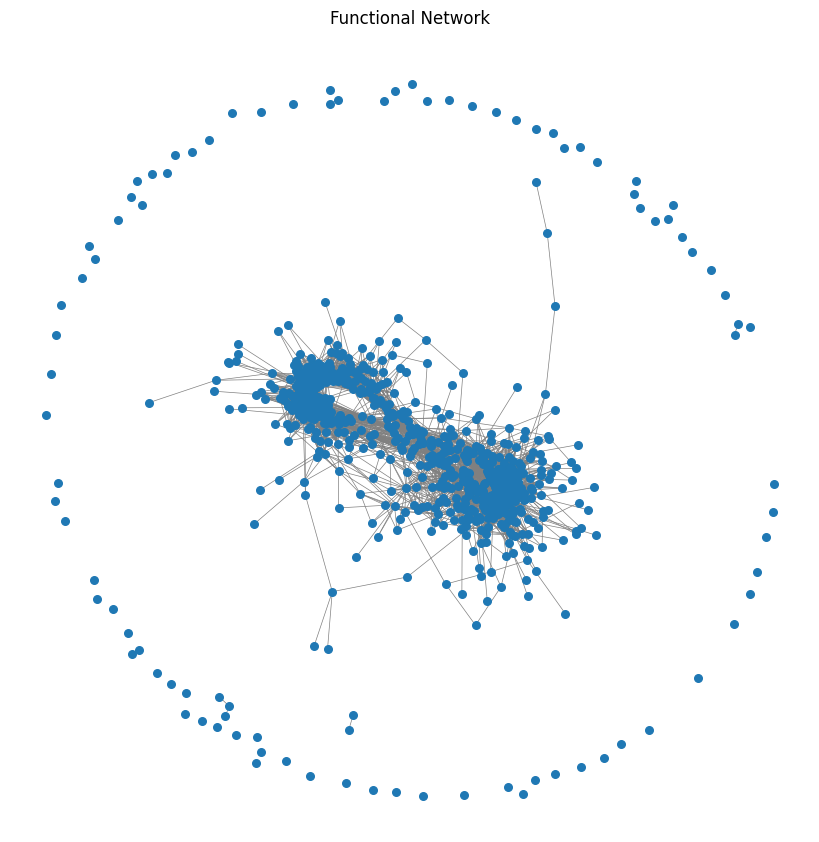

In [53]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


threshold = np.percentile(corr_matrix[np.triu_indices_from(corr_matrix, 1)], 95)

N = corr_matrix.shape[0]
G = nx.Graph()

# adicionar nós
for i in range(N):
    G.add_node(i)

# adicionar arestas
for i in range(N):
    for j in range(i+1, N):
        if corr_matrix[i, j] > threshold:
            G.add_edge(i, j, weight=corr_matrix[i, j])

# plot
plt.figure(figsize=(8,8))
pos = nx.spring_layout(G, seed=1)

nx.draw(
    G,
    pos,
    node_size=30,
    edge_color="gray",
    width=0.5
)

plt.title("Functional Network")
plt.show()

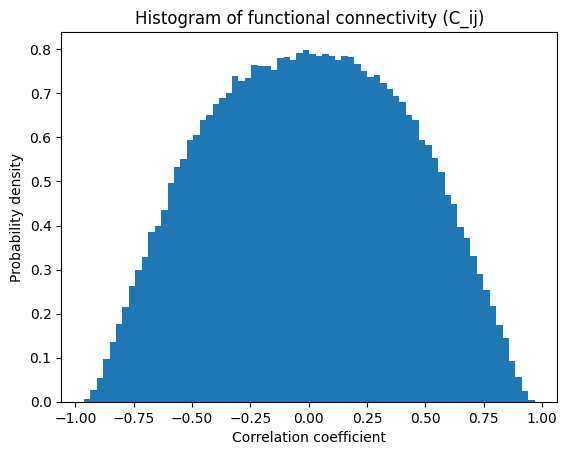

In [45]:
plt.hist(corr_matrix[np.triu_indices_from(corr_matrix, 1)],density=True, bins=70)
plt.title("Histogram of functional connectivity (C_ij)")
plt.xlabel("Correlation coefficient")
plt.ylabel("Probability density")
plt.show()